In [2]:
import pandas as pd
import glob
import os
import numpy as np
import time
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)

In [94]:
df = pd.read_csv(r"C:\Users\nadid\OneDrive - Technion\Desktop\Nadav\Studies\Technion\service_systems\project\final_files\merged_session_events.csv")

In [ ]:
df.columns = df.columns.str.replace(' ', '', regex=False)


df_sessions[df_sessions["id_session"] == 100053394][["id_session", "id_rep", "subsession", "chat_start_date", "chat_end_date"]]

In [ ]:
df_messages = pd.read_csv(r"C:\Users\nadid\Downloads\raw_session_events_before_events_8_9_19_07.csv")

df_messages.head(10)

Remove all spaces from olumn names:

In [ ]:
df_messages.columns = df_messages.columns.str.replace(' ', '', regex=False)


Total unique sessions:

In [ ]:
df_messages["id_session"].nunique()

In [ ]:
df_messages["outcome"].value_counts()

In [ ]:
df_messages[df_messages["outcome"] != 4].reset_index(drop = True)["id_session"].nunique()

Delete 80k silent abandment:

Number of agent messages:

In [ ]:
cond = (df_messages["event_type"] == 1) | (df_messages["event_type"] == 2) 

df_messages = df_messages[cond].reset_index(drop = True)

In [ ]:
df_messages["event_type_desc"].value_counts()

In [8]:
df_sessions = pd.read_csv(r"C:\Users\nadid\OneDrive - Technion\Desktop\Nadav\Studies\Technion\service_systems\project\merged_session.csv")

In [9]:
df_sessions.columns = df_sessions.columns.str.replace(' ', '', regex=False)


In [12]:
df_sessions[["id_session", "id_rep"]].isna().sum()

id_session    0
id_rep        0
dtype: int64

In [34]:
df_sessions[df_sessions[["id_session", "id_rep" ,"subsession"]].duplicated(keep= False)][["id_session", "id_rep" ,"subsession"]]

,id_session,id_rep,subsession


In [28]:
df_sessions[df_sessions["id_session"] == 100040542]

,id_site,id_session,id_visitor,chat_start_date,chat_start_time,queue_exit_date,queue_exit_time,chat_end_date,chat_end_time,queue_time,is_interactive,transfer_agent,transfer_reason,reassignment_skill,engagement_skill,answer_nps,answer_csat,chat_sentiment,score,origin,conv_type,first_conv,id_initiator,id_rep,subsession,outcome,outcome_desc,other_time,other_lines,other_number_words,other_number_chars,inner_wait,inner_wait_lines,visitor_duration,agent_duration,total_duration,visitor_number_words,agent_number_words,total_number_words,visitor_number_chars,agent_number_chars,total_number_chars,visitor_lines,agent_lines,total_lines,total_canned_lines,dur_dif,average_sent,min_sent,max_sent,n_sent,n_sent_pos,n_sent_neg,first_sent,last_sent,last_line_date,last_line_time,closer_time,id_rep_code,cust_prob_waiting,p_agent_duration,p_visitor_duration,p_inner_wait,p_other_time,p_dur_dif,source_file
1461,1,100040542,200115659,01/05/2017 12:17:28,1493641048,01/05/2017 12:17:30,1493641050,01/05/2017 12:17:55,1493641075,1,1,1,1,1,1,0,0,-8,0,2,1,1,30000174,30000174,1,2,served and transfered,0,0,0,0,0,0,19,0,27,28,0,28,141,0,141,2,0,2,0,8,-1.0,-1,-1,1,0,1,-1,-1,01/05/2017 12:17:48,1493641068,7,175,0.0,0.00,70.37,0.0,0.0,29.63,D01052017
1462,1,100040542,200115659,01/05/2017 12:17:55,1493641075,01/05/2017 12:17:57,1493641077,01/05/2017 12:19:05,1493641145,1,1,1,1,1,1,0,0,-8,0,2,1,1,30000352,30000352,2,2,served and transfered,0,0,0,0,0,0,57,0,70,2,0,2,9,0,9,1,0,1,0,13,0.0,0,0,0,0,0,0,0,01/05/2017 12:18:45,1493641125,20,353,0.0,0.00,81.43,0.0,0.0,18.57,D01052017
1463,1,100040542,200115659,01/05/2017 12:19:05,1493641145,01/05/2017 12:19:06,1493641146,01/05/2017 12:19:42,1493641182,1,1,1,1,1,1,0,0,-8,0,2,1,1,30000174,30000174,3,2,served and transfered,0,0,0,0,0,0,375,446,37,79,230,309,382,1208,1590,4,5,9,0,-784,0.0,0,0,0,0,0,0,0,01/05/2017 12:32:26,1493641946,0,175,0.0,1205.41,1013.51,0.0,0.0,-2118.92,D01052017
1464,1,100040542,200115659,01/05/2017 12:19:42,1493641182,01/05/2017 12:19:45,1493641185,01/05/2017 14:36:17,1493649377,2,2,1,0,0,1,0,0,-8,0,2,1,1,1,30000404,4,2,served and transfered,0,0,0,0,0,0,0,0,8195,0,0,0,0,0,0,0,0,0,0,8195,0.0,0,0,0,0,0,0,0,01/01/1970,0,0,405,0.0,0.00,0.00,0.0,0.0,100.00,D01052017


In [21]:
df[df["id_session"] == 100040542][[ "id_rep", "id_agent" , "start_date", "end_date", "event_type_desc"]]

,id_rep,id_agent,start_date,end_date,event_type_desc
811689,30000174.0,30000174,01/05/2017 12:17:29,01/05/2017 12:17:29,visitor_line
811690,30000174.0,30000174,01/05/2017 12:17:29,01/05/2017 12:17:48,visitor_line
811691,30000174.0,30000352,01/05/2017 12:17:48,01/05/2017 12:18:45,visitor_line
811692,30000174.0,30000174,01/05/2017 12:18:45,01/05/2017 12:22:24,rep_line
811693,30000174.0,30000174,01/05/2017 12:22:24,01/05/2017 12:24:21,visitor_line
811694,30000174.0,30000174,01/05/2017 12:24:21,01/05/2017 12:26:50,rep_line
811695,30000174.0,30000174,01/05/2017 12:26:50,01/05/2017 12:27:29,visitor_line
811696,30000174.0,30000174,01/05/2017 12:27:29,01/05/2017 12:27:55,rep_line
811697,30000174.0,30000174,01/05/2017 12:27:55,01/05/2017 12:31:02,visitor_line
811698,30000174.0,30000174,01/05/2017 12:31:02,01/05/2017 12:31:50,rep_line


In [29]:
df.head(5)

,id_site,id_session,id_visitor,start_date,start_time,end_date,end_time,duration,number_words,number_chars,number_lines,answer_canned,sentiment,accept_date,accept_time,read_date,read_time,event_type,event_type_desc,outcome,outcome_desc,subsession,delay,id_rep_code,sentiment_type,id_agent,id_agent_code,source_file,queue_exit_date,assignment_date,event_id,first_msg_dummy,id_rep
0,1,100000002,200064419,24/05/2017 22:57:02,1495666622,24/05/2017 22:57:02,1495666622,0,2,7,0,3,0,01/01/1970,0,01/01/1970,0,1,visitor_line,1,served,1,0,2,3,30001090,1091,D24052017,NaN,24/05/2017 22:57:04,0,1,30001090.0
1,1,100000002,200064419,24/05/2017 22:57:19,1495666639,24/05/2017 22:57:31,1495666651,12,60,322,0,2,0,24/05/2017 22:57:05,1495666625,24/05/2017 22:57:08,1495666628,2,rep_line,1,served,1,0,1091,4,30001090,1091,D24052017,NaN,NaN,3,0,30001090.0
2,1,100000002,200064419,24/05/2017 22:57:53,1495666673,24/05/2017 22:58:30,1495666710,37,15,66,0,2,0,24/05/2017 22:57:31,1495666651,24/05/2017 22:57:31,1495666651,1,visitor_line,1,served,1,0,1091,3,30001090,1091,D24052017,NaN,NaN,5,0,30001090.0
3,1,100000002,200064419,24/05/2017 22:58:52,1495666732,24/05/2017 22:59:26,1495666766,34,9,47,0,2,0,24/05/2017 22:57:54,1495666674,24/05/2017 22:58:53,1495666733,2,rep_line,1,served,1,0,1091,4,30001090,1091,D24052017,NaN,NaN,7,0,30001090.0
4,1,100000002,200064419,24/05/2017 23:00:21,1495666821,24/05/2017 23:00:26,1495666826,5,20,81,0,2,0,24/05/2017 22:59:41,1495666781,24/05/2017 22:59:41,1495666781,1,visitor_line,1,served,1,0,1091,3,30001090,1091,D24052017,NaN,NaN,9,0,30001090.0



### Working on cuncurencies 1.9.25:

In [3]:
df = pd.read_csv(r"C:\Users\nadid\Downloads\df_1_not_merged_2_merged_04_1_26.csv")



df.head(5)

,id_site,id_session,id_visitor,start_date,start_time,end_date,end_time,duration,number_words,number_chars,number_lines,answer_canned,sentiment,accept_date,accept_time,read_date,read_time,event_type,event_type_desc,outcome,outcome_desc,subsession,delay,id_rep_code,sentiment_type,id_agent,id_agent_code,source_file,queue_exit_date,assignment_date,event_id,first_msg_dummy,id_rep
0,1,100000002,200064419,24/05/2017 22:57:02,1495666622,24/05/2017 22:57:02,1495666622,0,2,7,0,3,0,01/01/1970,0,01/01/1970,0,1,visitor_line,1,served,1,0,2,3,30001090,1091,D24052017,NaN,24/05/2017 22:57:04,0,1,30001090.0
1,1,100000002,200064419,24/05/2017 22:57:19,1495666639,24/05/2017 22:57:31,1495666651,12,60,322,0,2,0,24/05/2017 22:57:05,1495666625,24/05/2017 22:57:08,1495666628,2,rep_line,1,served,1,0,1091,4,30001090,1091,D24052017,NaN,NaN,3,0,30001090.0
2,1,100000002,200064419,24/05/2017 22:57:53,1495666673,24/05/2017 22:58:30,1495666710,37,15,66,0,2,0,24/05/2017 22:57:31,1495666651,24/05/2017 22:57:31,1495666651,1,visitor_line,1,served,1,0,1091,3,30001090,1091,D24052017,NaN,NaN,5,0,30001090.0
3,1,100000002,200064419,24/05/2017 22:58:52,1495666732,24/05/2017 22:59:26,1495666766,34,9,47,0,2,0,24/05/2017 22:57:54,1495666674,24/05/2017 22:58:53,1495666733,2,rep_line,1,served,1,0,1091,4,30001090,1091,D24052017,NaN,NaN,7,0,30001090.0
4,1,100000002,200064419,24/05/2017 23:00:21,1495666821,24/05/2017 23:00:26,1495666826,5,20,81,0,2,0,24/05/2017 22:59:41,1495666781,24/05/2017 22:59:41,1495666781,1,visitor_line,1,served,1,0,1091,3,30001090,1091,D24052017,NaN,NaN,9,0,30001090.0


In [4]:
df.columns = df.columns.str.replace(' ', '', regex=False)

In [33]:
df.shape

(3622578, 33)

In [ ]:
rep_na = df[df["id_rep"].isna()].reset_index(drop = True)
rep_notna =  df[df["id_rep"].notna()].reset_index(drop = True)
print(rep_na.shape[0] + rep_notna.shape[0])



3622578


In [43]:
sessions_for_merge = df_sessions[["id_session", "subsession", "id_rep"]]

In [44]:
fixed_rep_na = rep_na.merge(sessions_for_merge, on = ["id_session", "subsession"], how = "left")
print(rep_na.shape, fixed_rep_na.shape)
print(fixed_rep_na.columns)

(4687, 33) (4689, 34)
Index(['id_site', 'id_session', 'id_visitor', 'start_date', 'start_time',
       'end_date', 'end_time', 'duration', 'number_words', 'number_chars',
       'number_lines', 'answer_canned', 'sentiment', 'accept_date',
       'accept_time', 'read_date', 'read_time', 'event_type',
       'event_type_desc', 'outcome', 'outcome_desc', 'subsession', 'delay',
       'id_rep_code', 'sentiment_type', 'id_agent', 'id_agent_code',
       'source_file', 'queue_exit_date', 'assignment_date', 'event_id',
       'first_msg_dummy', 'id_rep_x', 'id_rep_y'],
      dtype='object')


In [48]:
fixed_rep_na.rename(columns = {"id_rep_x": "old_id_rep", "id_rep_y": "id_rep"}, inplace =True)

fixed_rep_na.columns

Index(['id_site', 'id_session', 'id_visitor', 'start_date', 'start_time',
       'end_date', 'end_time', 'duration', 'number_words', 'number_chars',
       'number_lines', 'answer_canned', 'sentiment', 'accept_date',
       'accept_time', 'read_date', 'read_time', 'event_type',
       'event_type_desc', 'outcome', 'outcome_desc', 'subsession', 'delay',
       'id_rep_code', 'sentiment_type', 'id_agent', 'id_agent_code',
       'source_file', 'queue_exit_date', 'assignment_date', 'event_id',
       'first_msg_dummy', 'old_id_rep', 'id_rep'],
      dtype='object')

In [ ]:
df_events = pd.concat([fixed_rep_na, rep_notna])

df_events.shape


(3622580, 34)

In [73]:
df_events[~df_events["id_session"].isin([df_sessions["id_session"]])]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [89]:
df_sessions[df_sessions["id_session"] == 100053394][["id_session", "id_rep", "subsession", "chat_start_date", "chat_end_date"]]

,id_session,id_rep,subsession,chat_start_date,chat_end_date
49582,100053394,30001027,1,05/05/2017 17:44:55,05/05/2017 17:45:54
49583,100053394,30000612,2,05/05/2017 17:45:54,05/05/2017 21:50:46


In [93]:
df_events[(df_events["id_session"] == 100053394) &( df_events["id_rep"] == 30001027)][["id_session", "id_rep", "subsession", "start_date", "end_date"]].shape

(448, 5)

In [57]:
df_events = df_events[['id_site', 'id_session','id_rep', 'id_visitor', 'start_date', 'start_time',
       'end_date', 'end_time', 'duration', 'number_words', 'number_chars',
       'number_lines', 'answer_canned', 'sentiment', 'accept_date',
       'accept_time', 'read_date', 'read_time', 'event_type',
       'event_type_desc', 'outcome', 'outcome_desc', 'subsession', 'delay',
       'id_rep_code', 'sentiment_type', 'id_agent', 'id_agent_code',
       'source_file', 'queue_exit_date', 'assignment_date', 'event_id',
       'first_msg_dummy', 'old_id_rep']]


df_events.to_csv("df_evetns_fixed_id_rep_170125.csv", index= False)

In [22]:
cols = ["id_session", "subsession", "id_rep"]

df_sessions[df_sessions["id_session"] == 100359971][cols]

,id_session,subsession,id_rep
247926,100359971,1,30000106


In [30]:
df_sessions[df_sessions[["id_session", "subsession"]].duplicated(keep = False)][cols]

,id_session,subsession,id_rep
54827,100203197,1,30000629
63224,100203197,1,0
118207,100088559,1,30000680
131310,100088559,1,0


In [ ]:
df["id_session", "id_rep", "subsession"]

4687

In [ ]:
df["event_type_desc"].value_counts()

event_type_desc
visitor_line    1946105
rep_line        1676473
Name: count, dtype: int64

In [ ]:
df.columns

Index(['id_site', 'id_session', 'id_visitor', 'start_date', 'start_time',
       'end_date', 'end_time', 'duration', 'number_words', 'number_chars',
       'number_lines', 'answer_canned', 'sentiment', 'accept_date',
       'accept_time', 'read_date', 'read_time', 'event_type',
       'event_type_desc', 'outcome', 'outcome_desc', 'subsession', 'delay',
       'id_rep_code', 'sentiment_type', 'id_agent', 'id_agent_code',
       'source_file', 'queue_exit_date', 'assignment_date', 'event_id',
       'first_msg_dummy', 'id_rep'],
      dtype='object')

In [ ]:
df_sessions = pd.read_csv(r"C:\Users\nadid\Downloads\merged_session.csv")


df_sessions.columns

Index(['id_site', ' id_session', ' id_visitor', ' chat_start_date',
       ' chat_start_time', ' queue_exit_date', ' queue_exit_time',
       ' chat_end_date', ' chat_end_time', ' queue_time', ' is_interactive',
       ' transfer_agent', ' transfer_reason', ' reassignment_skill',
       ' engagement_skill', ' answer_nps', ' answer_csat', ' chat_sentiment',
       ' score', ' origin', ' conv_type', ' first_conv', ' id_initiator',
       ' id_rep', ' subsession', ' outcome', ' outcome_desc', ' other_time',
       ' other_lines', ' other_number_words', ' other_number_chars',
       ' inner_wait', ' inner_wait_lines', ' visitor_duration',
       ' agent_duration', ' total_duration', ' visitor_number_words',
       ' agent_number_words', ' total_number_words', ' visitor_number_chars',
       ' agent_number_chars', ' total_number_chars', ' visitor_lines',
       ' agent_lines', ' total_lines', ' total_canned_lines', ' dur_dif',
       ' average_sent', ' min_sent', ' max_sent', ' n_sent', ' n

In [ ]:
df_sessions.columns = df_sessions.columns.str.replace(' ', '', regex=False)
df_sessions_merge = df_sessions[["id_session", "id_rep", "queue_exit_date", "queue_exit_time" ,'chat_end_date', 'chat_end_time']]

In [ ]:
df_sessions_merge.head(5)

,id_session,id_rep,queue_exit_date,queue_exit_time,chat_end_date,chat_end_time
0,100000027,30000133,01/05/2017 09:14:58,1493630098,01/05/2017 09:38:52,1493631532
1,100000032,30000102,01/05/2017 01:21:27,1493601687,01/05/2017 01:46:15,1493603175
2,100000049,30000144,01/05/2017 18:14:31,1493662471,01/05/2017 21:01:17,1493672477
3,100000085,30000338,01/05/2017 13:40:44,1493646044,01/05/2017 15:03:40,1493651020
4,100000138,30000072,01/05/2017 04:47:43,1493614063,01/05/2017 08:57:00,1493629020


In [ ]:
df_sessions_merge.shape

(333463, 5)

In [ ]:
df_sessions_merge[df_sessions_merge[["id_session", "id_rep"]].duplicated(keep = False)]

,id_session,id_rep,queue_exit_date,chat_end_date,chat_end_time
1461,100040542,30000174,01/05/2017 12:17:30,01/05/2017 12:17:55,1493641075
1463,100040542,30000174,01/05/2017 12:19:06,01/05/2017 12:19:42,1493641182
23793,100342531,30000221,02/05/2017 15:16:22,02/05/2017 15:17:38,1493738258
23794,100342531,30000221,02/05/2017 15:21:16,02/05/2017 15:22:44,1493738564
55322,100218904,30000221,05/05/2017 22:24:58,05/05/2017 22:25:05,1494023105
55323,100218904,30000221,05/05/2017 22:28:04,05/05/2017 22:28:58,1494023338


In [ ]:
df_merged = df.merge(df_sessions_merge, on = ["id_session", "id_rep"], how = "left")

df_merged.shape

(3622590, 36)

In [ ]:
df_merged[df_merged[["id_session", "id_rep"]].duplicated(keep = False)].shape

(3615537, 36)

In [ ]:
df = df.sort_values(by = ["id_rep", "end_time"]).reset_index(drop = True)


df.head(10)

,id_site,id_session,id_visitor,start_date,start_time,end_date,end_time,duration,number_words,number_chars,number_lines,answer_canned,sentiment,accept_date,accept_time,read_date,read_time,event_type,event_type_desc,outcome,outcome_desc,subsession,delay,id_rep_code,sentiment_type,id_agent,id_agent_code,source_file,queue_exit_date,assignment_date,event_id,first_msg_dummy,id_rep
0,1,100115501,200171762,01/05/2017 00:06:20,1493597180,01/05/2017 00:06:20,1493597180,0,22,109,0,3,0,01/01/1970,0,01/01/1970,0,1,visitor_line,1,served,1,0,2,3,30000002,3,D01052017,NaN,01/05/2017 00:06:22,3708824,1,30000002.0
1,1,100115501,200171762,01/05/2017 00:06:22,1493597182,01/05/2017 00:06:31,1493597191,9,11,66,0,2,0,01/05/2017 00:06:23,1493597183,01/05/2017 00:06:23,1493597183,2,rep_line,1,served,1,0,3,4,30000002,3,D01052017,NaN,NaN,3708826,0,30000002.0
2,1,100115501,200171762,01/05/2017 00:06:31,1493597191,01/05/2017 00:06:39,1493597199,8,1,5,0,2,0,01/05/2017 00:06:31,1493597191,01/05/2017 00:06:31,1493597191,1,visitor_line,1,served,1,0,3,3,30000002,3,D01052017,NaN,NaN,3708827,0,30000002.0
3,1,100115501,200171762,01/05/2017 00:06:39,1493597199,01/05/2017 00:07:11,1493597231,36,26,10,0,2,0,01/05/2017 00:06:39,1493597199,01/05/2017 00:06:39,1493597199,2,rep_line,1,served,1,0,3,4,30000002,3,D01052017,NaN,NaN,3708828,0,30000002.0
4,1,100115501,200171762,01/05/2017 00:07:15,1493597235,01/05/2017 00:07:21,1493597241,6,1,2,0,2,0,01/05/2017 00:07:15,1493597235,01/05/2017 00:07:15,1493597235,1,visitor_line,1,served,1,0,3,3,30000002,3,D01052017,NaN,NaN,3708830,0,30000002.0
5,1,100115501,200171762,01/05/2017 00:07:21,1493597241,01/05/2017 00:11:28,1493597488,247,73,346,0,2,0,01/05/2017 00:07:21,1493597241,01/05/2017 00:07:21,1493597241,2,rep_line,1,served,1,0,3,4,30000002,3,D01052017,NaN,NaN,3708831,0,30000002.0
6,1,100115501,200171762,01/05/2017 00:11:28,1493597488,01/05/2017 00:12:09,1493597529,41,10,49,0,2,0,01/05/2017 00:11:28,1493597488,01/05/2017 00:11:28,1493597488,1,visitor_line,1,served,1,0,3,3,30000002,3,D01052017,NaN,NaN,3708832,0,30000002.0
7,1,100115501,200171762,01/05/2017 00:12:09,1493597529,01/05/2017 00:14:54,1493597694,186,78,292,0,2,0,01/05/2017 00:12:09,1493597529,01/05/2017 00:12:09,1493597529,2,rep_line,1,served,1,0,3,4,30000002,3,D01052017,NaN,NaN,3708833,0,30000002.0
8,1,100115501,200171762,01/05/2017 00:15:15,1493597715,01/05/2017 00:16:28,1493597788,73,36,155,0,2,0,01/05/2017 00:15:15,1493597715,01/05/2017 00:15:15,1493597715,1,visitor_line,1,served,1,0,3,3,30000002,3,D01052017,NaN,NaN,3708835,0,30000002.0
9,1,100115501,200171762,01/05/2017 00:16:28,1493597788,01/05/2017 00:17:56,1493597876,108,15,32,0,2,0,01/05/2017 00:16:28,1493597788,01/05/2017 00:16:28,1493597788,2,rep_line,1,served,1,0,3,4,30000002,3,D01052017,NaN,NaN,3708836,0,30000002.0


In [ ]:
df_sliced = df.head(100)

In [ ]:
#Inserting all messages sent by the agent to a dataframe:
filtered_rows = df[df['event_type'] == 2].reset_index(drop = True)
filtered_rows["choice_set"] = filtered_rows.index
# Start timing for loading time of the code:
start_time = time.time()

# this function indetifies concurrent sessions
def get_data_for_an_identifier(row):
    print('\r', row['index'], end='')
    # filtering the session level dataframe according to the agent number that is shown in filtered_rows (the filtered df with only the agent msg)
    # tmp_df is a session level dataframe that shows details of all the sessions that the given agent is a part of.
    tmp_df = df_sessions_merge[df_sessions_merge['id_rep'] == row['id_rep']]
    # identifying the sessions that started before the end_time of the agent's message in filtered_rows, 
    # and ended after the end_time of the agent's message.
    tmp_df = tmp_df[tmp_df['chat_end_time'] > row['end_time']]
    tmp_df = tmp_df[tmp_df['queue_exit_time'] < row['end_time']]
    # returning the time of msg, chosen session, and all the concurrent sessions in a list.
    return {"choice_set_id": row["choice_set"],'id_rep': row['id_rep'], 'event_id': row['event_id'], 'time':[row['end_time']],
            'session_id_chosen':[row['id_session']], 'concurrent_sessions':tmp_df['id_session'].tolist()}

# applying the function on filtered_rows
result_dicts  = filtered_rows.reset_index().apply(lambda row: get_data_for_an_identifier(row), axis=1)
# creating df with returned dictionary
aggregated_df = pd.DataFrame(list(result_dicts))
aggregated_df.head(50)

# End timing
end_time = time.time()

# Print execution time
print(f"Execution time: {end_time - start_time:.2f} seconds")

 167647295181121100512265611311221Execution time: 5951.50 seconds


In [ ]:
aggregated_df.to_csv("aggregated_df_09_01.csv", index=False)

In [ ]:
aggregated_df = pd.read_csv(r"C:\Users\nadid\OneDrive - Technion\Desktop\Nadav\Studies\Technion\service_systems\github\Service-system-research\concurencies_df.csv")

In [22]:
right_for_merge

,id_rep,event_id,id_agent
0,30001090.0,0,30001090
1,30001090.0,3,30001090
2,30001090.0,5,30001090
3,30001090.0,7,30001090
4,30001090.0,9,30001090
...,...,...,...
3622573,30000622.0,6614052,30000622
3622574,30000558.0,6614063,30000558
3622575,30000530.0,6614088,30000530
3622576,30000258.0,6614092,30000258


In [29]:
concurencies.columns

Index(['choice_set_id', 'id_rep', 'event_id', 'time', 'session_id_chosen',
       'concurrent_sessions', 'id_agent'],
      dtype='object')

In [ ]:
concurencies = aggregated_df.merge(right_for_merge, on = "event_id", how = "left")

concurencies = concurencies.drop(columns = "id_rep_y")
concurencies = concurencies.rename(columns = {"id_rep_x" : "id_rep"})

cols =['choice_set_id', 'id_agent', 'event_id', 'time', 'session_id_chosen',
       'concurrent_sessions', 'id_rep']

concurencies = concurencies[cols]


concurencies.to_csv("concurencies_df_11_1.csv", index = False)

In [3]:
concurrencies = pd.read_csv("concurencies_df_11_1.csv")


In [5]:
concurrencies.shape

(1676473, 7)

In [19]:
concurrencies['workload'] = concurrencies['concurrent_sessions'].apply(lambda x: len(x) / 11)


concurrencies["workload"].describe()

count    1.676473e+06
mean     6.122217e+00
std      2.832390e+00
min      1.818182e-01
25%      4.000000e+00
50%      6.000000e+00
75%      8.000000e+00
max      2.800000e+01
Name: workload, dtype: float64

In [ ]:
from ast import literal_eval

# We run literal_eval on these 3 columns to transform the strings that are shown as lists in the rows to actual lists
concurencies['concurrent_sessions'] = concurencies['concurrent_sessions'].apply(literal_eval)
concurencies['time'] = concurencies['time'].apply(literal_eval)
concurencies['session_id_chosen'] = concurencies['session_id_chosen'].apply(literal_eval)

# filtering empty concurrent sessions
filtered_agg = concurencies[concurencies['concurrent_sessions'].apply(lambda x: len(x) > 1)]
filtered_agg = filtered_agg.reset_index(drop = True)

#Exploding the dataframe (each session in the list is becoming a new row):
df_exploded = filtered_agg.explode('concurrent_sessions')
df_exploded = df_exploded.explode('time')
df_exploded = df_exploded.explode('session_id_chosen')
#Reseting index but saving the index column for choiceset:
df_exploded = df_exploded.reset_index()
df_exploded.head()

,index,choice_set_id,id_rep,event_id,time,session_id_chosen,concurrent_sessions,id_agent
0,0,6,30000002.0,5969558,1493598258,100247275,100115501,30000002
1,0,6,30000002.0,5969558,1493598258,100247275,100247275,30000002
2,1,7,30000002.0,5969563,1493598545,100247275,100115501,30000002
3,1,7,30000002.0,5969563,1493598545,100247275,100247275,30000002
4,2,8,30000002.0,1555125,1493599067,100045597,100045597,30000002


array([[<Axes: title={'center': 'workload'}>]], dtype=object)

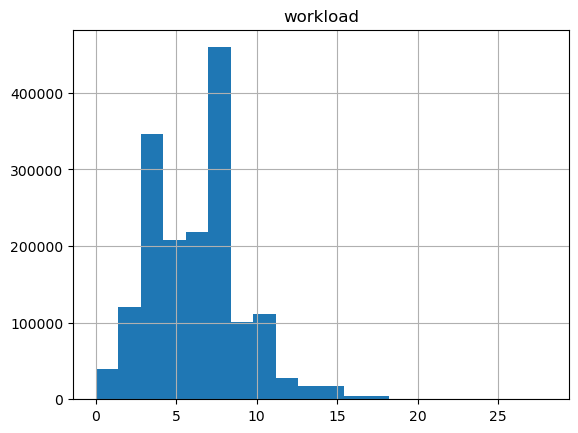

In [ ]:
aggregated_df.hist("workload", bins = 20)

In [ ]:
aggregated_df["workload"].describe().round(2)

count    1676473.00
mean           6.12
std            2.83
min            0.00
25%            4.00
50%            6.00
75%            8.00
max           28.00
Name: workload, dtype: float64

In [ ]:
aggregated_df[aggregated_df["id_rep"].isna()]

27

In [ ]:
filtered_rows[filtered_rows["id_rep"].isna()]#[["id_session", "id_rep", "outcome_desc"]]

,id_site,id_session,id_visitor,start_date,start_time,end_date,end_time,duration,number_words,number_chars,number_lines,answer_canned,sentiment,accept_date,accept_time,read_date,read_time,event_type,event_type_desc,outcome,outcome_desc,subsession,delay,id_rep_code,sentiment_type,id_agent,id_agent_code,source_file,queue_exit_date,assignment_date,event_id,first_msg_dummy,id_rep,choice_set
1676446,1,100269933,200006072,07/05/2017 13:19:43,1494163183,07/05/2017 14:27:45,1494167265,4082,23,125,0,3,0,07/05/2017 13:19:44,1494163184,07/05/2017 13:19:44,1494163184,2,rep_line,3,silent abandonment,1,0,2,4,30000195,196,D07052017,NaN,NaN,6166489,1,NaN,1676446
1676447,1,100261083,200157563,07/05/2017 13:19:05,1494163145,07/05/2017 14:28:32,1494167312,4167,32,179,0,3,0,07/05/2017 13:19:06,1494163146,07/05/2017 13:19:24,1494163164,2,rep_line,3,silent abandonment,1,0,2,4,30000195,196,D07052017,NaN,NaN,6091487,1,NaN,1676447
1676448,1,100204994,200051771,07/05/2017 20:18:18,1494188298,07/05/2017 22:41:40,1494196900,9683,157,45,0,3,0,07/05/2017 20:18:19,1494188299,07/05/2017 20:19:06,1494188346,2,rep_line,3,silent abandonment,1,0,2,4,30000543,544,D07052017,NaN,NaN,5487259,1,NaN,1676448
1676449,1,100173564,200023309,07/05/2017 21:04:49,1494191089,07/05/2017 22:44:46,1494197086,13923,109,119,0,3,0,07/05/2017 21:00:20,1494190820,07/05/2017 22:44:07,1494197047,2,rep_line,3,silent abandonment,1,0,2,4,30000543,544,D07052017,NaN,NaN,5039556,1,NaN,1676449
1676450,1,100128938,200013846,07/05/2017 14:45:23,1494168323,07/05/2017 22:45:00,1494197100,29623,77,49,0,3,0,07/05/2017 22:37:37,1494196657,07/05/2017 22:37:37,1494196657,2,rep_line,3,silent abandonment,1,0,2,4,30000195,196,D07052017,NaN,NaN,4073599,1,NaN,1676450
1676451,1,100281277,200143297,07/05/2017 21:19:38,1494191978,07/05/2017 22:54:46,1494197686,5967,115,116,0,3,0,07/05/2017 21:19:38,1494191978,07/05/2017 21:19:38,1494191978,2,rep_line,3,silent abandonment,1,0,2,4,30000543,544,D07052017,NaN,NaN,6259559,1,NaN,1676451
1676452,1,100281432,200035285,07/05/2017 21:54:40,1494194080,07/05/2017 22:58:48,1494197928,4171,109,87,0,3,0,07/05/2017 21:54:41,1494194081,07/05/2017 21:55:54,1494194154,2,rep_line,3,silent abandonment,1,0,2,4,30000543,544,D07052017,NaN,NaN,6260740,1,NaN,1676452
1676453,1,100002922,200230443,07/05/2017 21:07:05,1494191225,07/05/2017 23:00:01,1494198001,7103,110,98,0,3,0,07/05/2017 21:01:30,1494190890,07/05/2017 22:59:39,1494197979,2,rep_line,3,silent abandonment,1,0,2,4,30000543,544,D07052017,NaN,NaN,99555,1,NaN,1676453
1676454,1,100300726,200079405,07/05/2017 21:08:16,1494191296,07/05/2017 23:15:25,1494198925,8273,95,81,0,3,0,07/05/2017 21:08:16,1494191296,07/05/2017 21:08:24,1494191304,2,rep_line,3,silent abandonment,1,0,2,4,30000543,544,D07052017,NaN,NaN,6379479,1,NaN,1676454
1676455,1,100205545,200095024,07/05/2017 22:01:59,1494194519,07/05/2017 23:19:54,1494199194,5276,165,121,0,3,0,07/05/2017 21:06:18,1494191178,07/05/2017 23:11:14,1494198674,2,rep_line,3,silent abandonment,1,0,2,4,30000543,544,D07052017,NaN,NaN,5494067,1,NaN,1676455


In [ ]:
filtered_rows[["id_agent", "id_rep"]].head(30)

,id_agent,id_rep
0,30000002,30000002.0
1,30000002,30000002.0
2,30000002,30000002.0
3,30000002,30000002.0
4,30000002,30000002.0
5,30000002,30000002.0
6,30000002,30000002.0
7,30000002,30000002.0
8,30000002,30000002.0
9,30000002,30000002.0
